# Outbreak regression baseline on `feature_county_day`

Fits a **logistic regression** predicting `target_outbreak_next_7d` — will this county have a
USDA-confirmed HPAI poultry detection in the next 7 days? — from the environmental, spatial and
exposure variables in the modeling surface. This is the **in-house baseline** that sentiment will
later be tested against for incremental lift; it is not an attempt to reproduce Zou et al.

## What this notebook is careful about

Four things will silently produce a wrong-but-plausible answer on this dataset. Each is handled
explicitly below, and each is worth understanding before changing anything.

1. **The split is temporal, never random.** County-days are massively autocorrelated in both space
   and time. A random train/test split lets the model see the same outbreak cluster on both sides
   and reports a fantasy score.
2. **The positive class is ~0.3%.** ROC-AUC looks impressive at that base rate almost regardless of
   the model. **Average precision (PR-AUC) against the base rate is the honest headline**, so both
   are reported.
3. **Negatives are subsampled in TRAINING ONLY; the test set stays complete.** Under case-control
   sampling the logistic slopes are unbiased and only the intercept shifts, so it is corrected
   analytically before any probability is evaluated. Had the test set also been sampled, every
   precision-based metric would be inflated.
4. **NULL is not zero.** Suppressed NASS inventory and "no outbreak in the past 365 days" are
   missing/censored, not zero, and are given explicit indicator columns rather than being filled.

Requires the modeling extra and a running Cloud SQL proxy:

```bash
uv sync --extra modeling --extra dev
.\cloud-sql-proxy.exe harvard-capstone-499102:us-central1:h5n1-pg --port 5433
uv run --extra modeling --extra dev jupyter lab
```

In [1]:
# --- configuration -------------------------------------------------------------
# Every analysis choice worth arguing about is a constant here.

STUDY_START = "2022-02-08"   # first US poultry detection; earlier days are all-zero DV
SPLIT_DATE  = "2025-01-01"   # train < SPLIT_DATE <= test. TEMPORAL, never random.

# Keep every training positive, sample training negatives. Test is untouched.
NEG_SAMPLE_RATE = 0.05
RANDOM_STATE    = 20260728

# fact_bird_density stops 2025-07-10 (the NABBP source's own extent, not a load bug:
# releases are annual and the current one is "1960-2025 retrieved 2025-07-11"). That is
# inside the test window, so banding features would be structurally zero for most of the
# test period while being live in training -- a train/test distribution shift that has
# nothing to do with epidemiology. Excluded by default.
INCLUDE_BANDING = False

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from h5n1.db import get_engine

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

# --- plot style: recessive grid, thin marks, text in ink rather than series color ---
INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9.5,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

## 1. Load

Filtering happens server-side. Three predicates matter:

- `is_conus` — Alaska and Hawaii have no weather, no migration axis and no proximity rows, so they
  would enter as ~300k rows of structural NULLs.
- `target_complete_7d` — near the data horizon the forward window is truncated, so its zeros are
  partly fictional. Dropping these is what stops the model being rewarded for a quiet tail.
- The negative subsample applies **only before `SPLIT_DATE`**.

In [3]:
QUERY = f"""
SELECT fips, day, state,
       target_outbreak_next_7d,
       outbreak, own_outbreaks_7d, own_outbreaks_21d, own_outbreaks_60d,
       nbr_infected_counties_7d, nbr_infected_counties_21d, nbr_infected_counties_60d,
       nbr_infections_7d, nbr_infections_21d, nbr_infections_60d,
       nbr_wild_detections_7d, nbr_wild_detections_21d, nbr_wild_detections_60d,
       wild_detections_7d, wild_detections_21d, wild_detections_60d,
       band_count_21d, nbr_band_count_21d, has_band_coverage,
       days_since_outbreak_county, days_since_outbreak_neighbor,
       breeding_side_pressure, wintering_side_pressure,
       temp_min_7d_c, temp_max_7d_c, precip_7d_mm, precip_days_7d,
       poultry_operations, layer_operations, broiler_operations,
       turkey_operations, duck_operations, layer_inventory,
       population, pop_density_sqmi, n_neighbors, doy_sin, doy_cos
FROM feature_county_day
WHERE is_conus
  AND target_complete_7d
  AND day >= '{STUDY_START}'
  AND (
        day >= '{SPLIT_DATE}'          -- test period: complete, never sampled
     OR target_outbreak_next_7d        -- training positives: keep all
     OR random() < {NEG_SAMPLE_RATE}   -- training negatives: sample
      )
"""

df = pd.read_sql(QUERY, get_engine())
df["day"] = pd.to_datetime(df["day"])
print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"date range {df.day.min().date()} .. {df.day.max().date()}")

1,912,301 rows x 42 columns
date range 2022-02-08 .. 2026-07-14


In [4]:
# --- audit: confirm the sampling did what we think, and see the real base rate ----
is_train = df.day < SPLIT_DATE
audit = pd.DataFrame({
    "rows":      [is_train.sum(), (~is_train).sum()],
    "positives": [df.loc[is_train, "target_outbreak_next_7d"].sum(),
                  df.loc[~is_train, "target_outbreak_next_7d"].sum()],
}, index=["train (negatives sampled)", "test (complete)"])
audit["positive_rate"] = (audit.positives / audit.rows).map("{:.4%}".format)
display(audit)

print("\nTest-set positive rate is the POPULATION base rate -- the number every")
print("precision metric below has to be judged against.")
print(f"\nMissingness (NULL != 0 -- these get indicators, not fillna(0)):")
print(df[["days_since_outbreak_county", "days_since_outbreak_neighbor",
          "layer_inventory", "temp_max_7d_c"]].isna().mean().map("{:.2%}".format).to_string())

,rows,positives,positive_rate
train (negatives sampled),171821,8136,4.7352%
test (complete),1740480,4366,0.2509%



Test-set positive rate is the POPULATION base rate -- the number every
precision metric below has to be judged against.

Missingness (NULL != 0 -- these get indicators, not fillna(0)):
days_since_outbreak_county      91.35%
days_since_outbreak_neighbor    65.58%
layer_inventory                 11.21%
temp_max_7d_c                    0.16%


## 2. Feature preparation

Three transformations, each for a stated reason:

- **`log1p` on every count/exposure column.** Layer inventory spans 0 to 13.7M and poultry
  operations 0 to ~2,000; untransformed, a handful of egg-belt counties dominate the fit.
- **Censored recency → capped value + indicator.** `days_since_outbreak_*` is NULL when nothing
  happened in the trailing 365 days. That is *right-censoring*, not missingness: filling it with 0
  would say "an outbreak just happened here."
- **Suppressed inventory → median + indicator.** NASS withholds layer inventory for 348 counties
  that demonstrably behave like mid-to-large layer operations. The indicator lets the model price
  the withholding itself, which carries information.

In [5]:
COUNT_COLS = [
    "own_outbreaks_7d", "own_outbreaks_21d", "own_outbreaks_60d",
    "nbr_infected_counties_7d", "nbr_infected_counties_21d", "nbr_infected_counties_60d",
    "nbr_infections_7d", "nbr_infections_21d", "nbr_infections_60d",
    "nbr_wild_detections_7d", "nbr_wild_detections_21d", "nbr_wild_detections_60d",
    "wild_detections_7d", "wild_detections_21d", "wild_detections_60d",
    "breeding_side_pressure", "wintering_side_pressure",
    "poultry_operations", "layer_operations", "broiler_operations",
    "turkey_operations", "duck_operations", "population",
]
PASSTHROUGH = ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm",
               "doy_sin", "doy_cos", "n_neighbors"]

X = pd.DataFrame(index=df.index)

for c in COUNT_COLS:
    X[f"log_{c}"] = np.log1p(df[c].clip(lower=0))

# Censored recency: cap beyond the 365-day lookback, and flag that it was censored.
for c in ["days_since_outbreak_county", "days_since_outbreak_neighbor"]:
    X[f"{c}_censored"] = df[c].isna().astype(int)
    X[c] = df[c].fillna(400) / 100.0     # /100 keeps it on a comparable scale

# Suppressed NASS inventory: indicator + median fill. Never a plain 0.
X["layer_inventory_suppressed"] = (df.layer_inventory.isna() & (df.layer_operations > 0)).astype(int)
X["log_layer_inventory"] = np.log1p(df.layer_inventory.fillna(df.layer_inventory.median()))

if INCLUDE_BANDING:
    X["log_band_count_21d"] = np.log1p(df.band_count_21d.clip(lower=0))
    X["log_nbr_band_count_21d"] = np.log1p(df.nbr_band_count_21d.clip(lower=0))

for c in PASSTHROUGH:
    X[c] = df[c]

# Weather is a MEASUREMENT: a NULL means the station did not report, not 0 degrees.
# Median-fill with an indicator so the model can separate "cold" from "unobserved".
X["weather_missing"] = df.temp_max_7d_c.isna().astype(int)
for c in ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm"]:
    X[c] = X[c].fillna(X.loc[df.day < SPLIT_DATE, c].median())

y = df.target_outbreak_next_7d.astype(int)
print(f"design matrix: {X.shape[0]:,} x {X.shape[1]}   NaNs remaining: {int(X.isna().sum().sum())}")

design matrix: 1,912,301 x 36   NaNs remaining: 0


In [6]:
# --- leakage assertion: no target_* or same-day outbreak column may reach the model ---
banned = [c for c in X.columns if c.startswith("target_") or c == "outbreak"]
assert not banned, f"LEAKAGE: {banned}"
assert X.isna().sum().sum() == 0, "NaNs in design matrix"
print("leakage check passed -- no forward-looking or same-day columns in X")
print("\nNOTE: own_outbreaks_7d/21d/60d ARE included. They are past-only [day-w, day-1]")
print("and legitimately knowable, but they are also the strongest single predictor.")
print("Set them aside if you want to see what the environmental signal does alone.")

leakage check passed -- no forward-looking or same-day columns in X

NOTE: own_outbreaks_7d/21d/60d ARE included. They are past-only [day-w, day-1]
and legitimately knowable, but they are also the strongest single predictor.
Set them aside if you want to see what the environmental signal does alone.


## 3. Temporal split and fit

`class_weight="balanced"` is deliberately **not** used. Negatives are already subsampled, and
stacking class weights on top would distort the intercept a second time in a way the analytic
correction below does not account for.

In [7]:
train, test = df.day < SPLIT_DATE, df.day >= SPLIT_DATE
X_tr, X_te, y_tr, y_te = X[train], X[test], y[train], y[test]

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
)
model.fit(X_tr, y_tr)

# --- prior correction for case-control sampling -------------------------------
# Positives kept with probability 1, negatives with probability NEG_SAMPLE_RATE.
# The slopes are unbiased; only the intercept is offset, by log(tau_1 / tau_0).
lr = model.named_steps["logisticregression"]
print(f"fitted intercept   {lr.intercept_[0]:+.4f}")
lr.intercept_ += np.log(NEG_SAMPLE_RATE)
print(f"corrected intercept {lr.intercept_[0]:+.4f}   (shift {np.log(NEG_SAMPLE_RATE):+.4f})")

p_te = model.predict_proba(X_te)[:, 1]

fitted intercept   -3.8371
corrected intercept -6.8328   (shift -2.9957)


In [8]:
base_rate = y_te.mean()
scores = pd.Series({
    "test rows":            f"{len(y_te):,}",
    "test positives":       f"{int(y_te.sum()):,}",
    "base rate":            f"{base_rate:.4%}",
    "ROC-AUC":              f"{roc_auc_score(y_te, p_te):.4f}",
    "PR-AUC (avg prec.)":   f"{average_precision_score(y_te, p_te):.4f}",
    "PR-AUC lift vs base":  f"{average_precision_score(y_te, p_te) / base_rate:.1f}x",
    "Brier score":          f"{brier_score_loss(y_te, p_te):.6f}",
    "mean predicted prob":  f"{p_te.mean():.4%}",
})
print(scores.to_string())
print("\nRead PR-AUC against the base rate, not against 1.0. ROC-AUC is flattering at")
print("this prevalence -- a model can score well on it while being useless in practice.")

test rows              1,740,480
test positives             4,366
base rate                0.2509%
ROC-AUC                   0.8759
PR-AUC (avg prec.)        0.1162
PR-AUC lift vs base        46.3x
Brier score             0.002545
mean predicted prob      0.3768%

Read PR-AUC against the base rate, not against 1.0. ROC-AUC is flattering at
this prevalence -- a model can score well on it while being useless in practice.


## 4. Diagnostics

Precision-recall against the base rate is the operational question: *if we flag the top N
county-days, what fraction are real?* The calibration curve then asks whether the predicted
probabilities can be believed as probabilities — which matters if these ever feed a decision rule.

findfont: Failed to find font weight 600, now using 700.


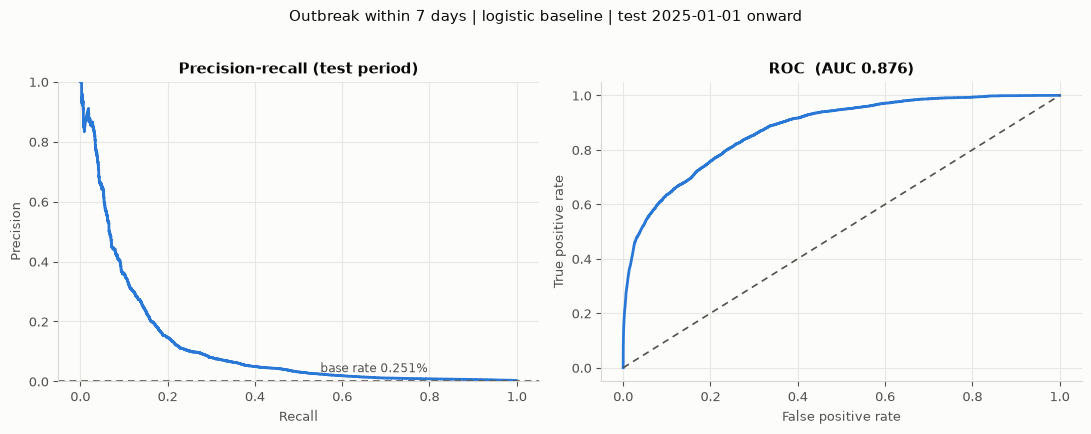

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

prec, rec, _ = precision_recall_curve(y_te, p_te)
axes[0].plot(rec, prec, color=BLUE)
axes[0].axhline(base_rate, color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[0].annotate(f"base rate {base_rate:.3%}", (0.55, base_rate), textcoords="offset points",
                 xytext=(0, 6), color=INK_2, fontsize=8.5)
axes[0].set(xlabel="Recall", ylabel="Precision", ylim=(0, 1),
            title="Precision-recall (test period)")

fpr, tpr, _ = roc_curve(y_te, p_te)
axes[1].plot(fpr, tpr, color=BLUE)
axes[1].plot([0, 1], [0, 1], color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[1].set(xlabel="False positive rate", ylabel="True positive rate",
            title=f"ROC  (AUC {roc_auc_score(y_te, p_te):.3f})")

fig.suptitle(f"Outbreak within 7 days | logistic baseline | test {SPLIT_DATE} onward",
             fontsize=10.5, color=INK, y=1.02)
fig.tight_layout()
plt.show()

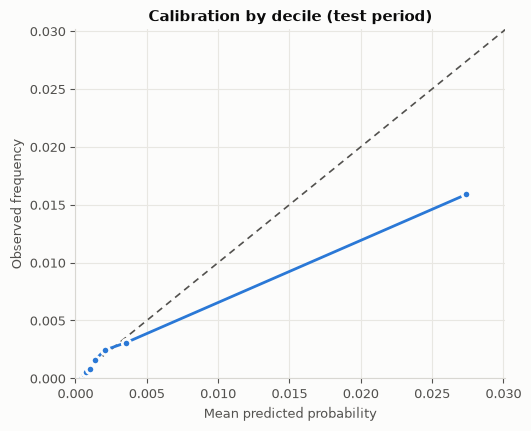

,pred,obs,n
bin,,,
0,0.0193%,0.0023%,174048
1,0.0325%,0.0138%,174048
2,0.0446%,0.0155%,174048
3,0.0586%,0.0402%,174048
4,0.0765%,0.0592%,174048
5,0.1011%,0.0781%,174048
6,0.1381%,0.1586%,174048
7,0.2039%,0.2436%,174048
8,0.3530%,0.3080%,174048


In [10]:
# --- calibration: decile bins of predicted probability vs observed frequency ---
cal = pd.DataFrame({"p": p_te, "y": y_te.values})
cal["bin"] = pd.qcut(cal.p, 10, labels=False, duplicates="drop")
g = cal.groupby("bin").agg(pred=("p", "mean"), obs=("y", "mean"), n=("y", "size"))

fig, ax = plt.subplots(figsize=(5.4, 4.4))
lim = max(g.pred.max(), g.obs.max()) * 1.1
ax.plot([0, lim], [0, lim], color=INK_2, lw=1.2, ls=(0, (4, 3)))
ax.plot(g.pred, g.obs, color=BLUE, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=2)
ax.set(xlabel="Mean predicted probability", ylabel="Observed frequency",
       title="Calibration by decile (test period)", xlim=(0, lim), ylim=(0, lim))
fig.tight_layout()
plt.show()

display(g.assign(pred=lambda d: d.pred.map("{:.4%}".format),
                 obs=lambda d: d.obs.map("{:.4%}".format)))

## 5. Inference — coefficients with county-clustered standard errors

`sklearn` gives no standard errors, and naive ones would be badly overconfident here: ~1,600
observations per county are anything but independent draws. Refit with `statsmodels` and cluster
the covariance by `fips`, so the standard errors reflect roughly the number of *counties*, not the
number of county-days.

Fitted on the **training window only**, so the test period stays untouched for evaluation.

In [11]:
Xs = (X_tr - X_tr.mean()) / X_tr.std().replace(0, 1)   # standardized -> comparable ORs
Xs = sm.add_constant(Xs, has_constant="add")

# Discrete models take cov_type in fit() itself -- get_robustcov_results() is an
# OLS/GLM-only method and raises AttributeError on a LogitResults object.
res = sm.Logit(y_tr.values, Xs).fit(
    disp=False, method="lbfgs", maxiter=200,
    cov_type="cluster", cov_kwds={"groups": df.loc[train, "fips"].values},
)

ci = np.asarray(res.conf_int())    # DataFrame when the design matrix is a DataFrame
coef = pd.DataFrame({
    "odds_ratio": np.exp(np.asarray(res.params)),
    "ci_low":     np.exp(ci[:, 0]),
    "ci_high":    np.exp(ci[:, 1]),
    "p_value":    np.asarray(res.pvalues),
}, index=Xs.columns)
coef["significant"] = coef.p_value < 0.05
coef = coef.drop("const").sort_values("odds_ratio", ascending=False)   # kept for the odds-ratio plot below

print("Odds ratio per 1 SD increase. Clustered by county (n_clusters = "
      f"{df.loc[train, 'fips'].nunique():,}).\n")

# --- rank by CI precision instead of effect size: narrowest (most tightly estimated) ---
# --- confidence interval first, all variables shown, not just a top-N cut ------------
coef["ci_width"] = coef.ci_high - coef.ci_low
by_ci = coef.sort_values("ci_width", ascending=True)
pd.set_option("display.max_rows", None)
print(f"All {len(by_ci)} variables, ranked by confidence-interval width -- narrowest "
      "(most precisely estimated) first:\n")
display(by_ci[["odds_ratio", "ci_low", "ci_high", "ci_width", "p_value", "significant"]].style.format(
    {"odds_ratio": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}", "ci_width": "{:.3f}", "p_value": "{:.2e}"}))

Odds ratio per 1 SD increase. Clustered by county (n_clusters = 3,108).

All 36 variables, ranked by confidence-interval width -- narrowest (most precisely estimated) first:



,odds_ratio,ci_low,ci_high,ci_width,p_value,significant
weather_missing,0.884,0.867,0.901,0.035,1.58e-34,True
log_wild_detections_7d,1.037,0.999,1.077,0.078,5.66e-02,False
log_nbr_wild_detections_7d,1.057,1.012,1.103,0.091,1.27e-02,True
log_own_outbreaks_7d,1.178,1.130,1.228,0.098,8.77e-15,True
log_wild_detections_21d,1.073,1.014,1.135,0.121,1.39e-02,True
log_wintering_side_pressure,1.252,1.190,1.319,0.129,9.85e-18,True
log_breeding_side_pressure,1.283,1.220,1.350,0.130,5.62e-22,True
doy_sin,0.786,0.721,0.855,0.134,2.74e-08,True
log_own_outbreaks_21d,1.146,1.080,1.216,0.136,6.39e-06,True
precip_7d_mm,0.934,0.866,1.008,0.143,8.08e-02,False


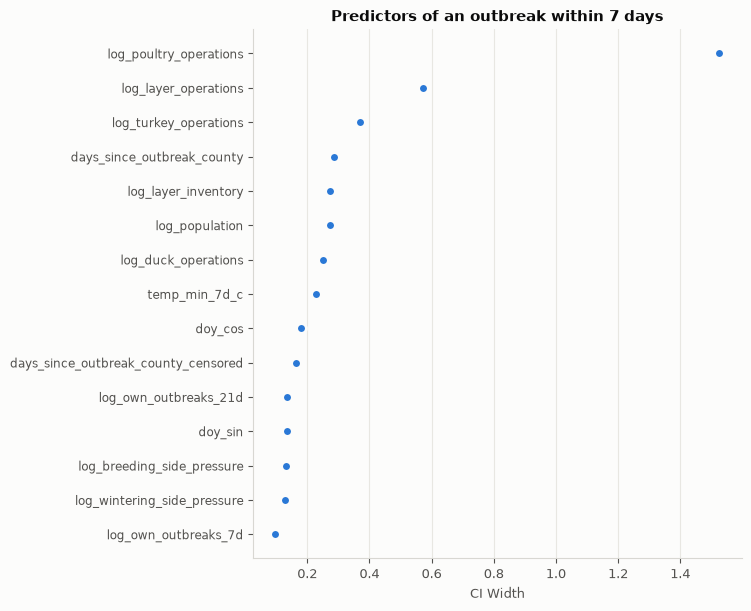

In [12]:
top = pd.concat([coef.head(9), coef.tail(6)]).sort_values("ci_width")
fig, ax = plt.subplots(figsize=(7.6, 6.2))
ypos = np.arange(len(top))

# ax.hlines(ypos, top.ci_low, top.ci_high, color=BLUE, lw=2, alpha=0.45)
ax.plot(top.ci_width, ypos, "o", color=BLUE, markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2, linestyle="none")
# ax.axvline(1.0, color=INK_2, lw=1.2, ls=(0, (4, 3)))

ax.set_yticks(ypos)
ax.set_yticklabels(top.index, fontsize=8.5)
# ax.set_xscale("log")
ax.set(xlabel="CI Width",
       title="Predictors of an outbreak within 7 days")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 6. What this is and is not

**Is:** an honest, leakage-checked, temporally-split baseline with population-valid test metrics —
the reference number that sentiment has to beat.

**Is not:** a tuned model. Deliberately absent, in rough order of expected payoff:

1. **No regularization path or nonlinear model.** A gradient-boosted tree will almost certainly
   beat this; logistic regression was chosen because its coefficients are interpretable and its
   failure modes are visible.
2. **No spatial random effect.** Clustered standard errors fix the *inference*, not the *fit* —
   counties still enter as independent rows.
3. **`own_outbreaks_*` probably dominates.** An already-infected county staying infected is real
   signal but a weak early-warning claim. Re-run with those columns dropped to see what the
   environmental and spatial features carry on their own.
4. **Banding features excluded** (`INCLUDE_BANDING = False`) because `fact_bird_density` ends
   2025-07-10, inside the test window.
5. **No permutation control yet.** The project's methodological control — shuffling a feature block
   and confirming performance degrades — is the natural next cell, and is what will make the
   eventual sentiment claim credible.
6. **Poultry exposure is a static 2022 snapshot** applied across 2022–2026, so it cannot reflect
   depopulation and restocking caused by the very outbreaks being modeled.

##  7. Iterate Testing With Various Angles and Distances of the Breeding Pressure 


## Testing Range
In the previous logistic regression, we used the breeding/wintering side pressure at the Angle of SECTOR_HALF_WIDTH_DEG = 45, Distance at the Radius_km = 300, and DECAY_SCALE_KM = 150 or 1/2 of the distance. 
We are going to test with other angle/distance/decay values and compared to the precision-recall and ROC scores. 

| Variables | Range | Testing Range |
|-----------|-------|---------------|
| Angle | [0 degree, 180 degree]|[0,45,90,135,180]|
| Distance | [0 km, 400 km]|[0,100,200,300,400]|
| Decay scale | No limit weight = exp(-distance_km / DECAY_SCALE_KM))|[1/2, 1/3, 1/4, 1/5, 1/6] of distance|

We will begin with this testing range, then continue to add more as needed.

**Clarification about Angle** : SECTOR_HALF_WIDTH_DEG = 45 means: take the axis bearing (e.g. breeding_bearing_deg), and keep any neighbor whose bearing is within 45° of it in either direction — i.e., 45° clockwise and 45° counterclockwise, forming a 90°-wide cone centered on the axis bearing.

## How to execute editing Angle, Distance, and Decay?
select raw tables county_proximity, county_migration_axis, fact_wild_bird_detection -> re-implement angle, distance, and angle on the notebook -> intergrate it to current df -> run logistic regression -> store the testing values.

## What are the Benchmark or Measuring Values

|Recording Measurements|Definition|
|----------------------|----------|
|Precision| (TP/(TP+FP))|
|Recall| (TP/(TP+FN))|
|PR-AUC| The area under the precision-recall curve|
|ROC-AUC| The area under the True positive vs False positive rate curve|
|PR base rate| Percent of Positive in the data|
|lift| PR-AUC/base rate|

In [13]:
df_without_side_pressure = df.drop(columns=['breeding_side_pressure','wintering_side_pressure'])

In [14]:
# --- read-only pulls: the raw geometry + detections behind migration pressure -----
# feature_county_day only has the ALREADY-BUILT breeding_side_pressure /
# wintering_side_pressure -- computed once, offline, by
# h5n1/features/migration_pressure.py with its own fixed constants (45 deg / 300 km /
# 150 km / 21 days) and upserted into feature_migration_pressure. To try other
# angles/radii/decay scales here we rebuild the feature LOCALLY from the raw tables
# below. Every query is a plain SELECT -- nothing is written back to the database.
from sqlalchemy import text

from h5n1.sources.migration import angular_diff

with get_engine().connect() as conn:
    prox_raw = pd.DataFrame(
        conn.execute(text(
            "SELECT fips, neighbor_fips, distance_km, bearing_deg FROM county_proximity"
        )).all(),
        columns=["fips", "neighbor_fips", "distance_km", "bearing_deg"],
    )
    axis_raw = pd.DataFrame(
        conn.execute(text(
            "SELECT fips, breeding_bearing_deg, wintering_bearing_deg FROM county_migration_axis"
        )).all(),
        columns=["fips", "breeding_bearing_deg", "wintering_bearing_deg"],
    )
    det_raw = pd.DataFrame(
        conn.execute(text(
            "SELECT fips, day, detection_count FROM fact_wild_bird_detection"
        )).all(),
        columns=["fips", "day", "detection_count"],
    )

print(f"county_proximity          {len(prox_raw):,} directed pairs (stored out to 400 km)")
print(f"county_migration_axis     {len(axis_raw):,} counties")
print(f"fact_wild_bird_detection  {len(det_raw):,} county-days")

county_proximity          787,620 directed pairs (stored out to 400 km)
county_migration_axis     3,108 counties
fact_wild_bird_detection  8,465 county-days


In [15]:
# --- local, parameterized reimplementation of h5n1/features/migration_pressure.py ---
# Identical math to the production module, but sector_half_width_deg / radius_km /
# decay_scale_km / lag_days are function ARGUMENTS instead of module constants, so
# different values can be swept here without touching the DB or feature_migration_pressure.
# Production defaults: 45 deg / 300 km / 150 km / 21 days.
#
# Hard bounds (see h5n1/features/migration_pressure.py and sql/seed_migration.py):
#   sector_half_width_deg in [0, 180]  -- angular_diff() is confined to that range;
#                                          180 = no directional filter at all
#   radius_km             in [0, 400]  -- county_proximity is only stored out to
#                                          R_MAX_KM = 400 km; past 400 needs re-seeding
#   decay_scale_km        >= 0         -- no stored cap; radius_km == 0 yields zero
#                                          pressure regardless of decay (no edges pass
#                                          the distance filter, so no division ever runs)

LAG_DAYS_DEFAULT = 21


def sector_edges(prox, axis, bearing_col, sector_half_width_deg, radius_km, decay_scale_km):
    e = prox.merge(axis[["fips", bearing_col]], on="fips")
    e = e[e["distance_km"] <= radius_km]
    e = e[angular_diff(e["bearing_deg"], e[bearing_col]) <= sector_half_width_deg]
    e = e.assign(weight=np.exp(-e["distance_km"] / decay_scale_km))
    return e[["fips", "neighbor_fips", "weight"]]


def side_pressure(edges, det, lag_days):
    j = edges.merge(det, left_on="neighbor_fips", right_on="fips", suffixes=("", "_src"))
    j["contrib"] = j["weight"] * j["detection_count"]
    daily = j.groupby(["fips", "day"], as_index=False)["contrib"].sum()  # (C, d', value)

    # spread each source day d' across the trailing window: it feeds days d'+1 .. d'+lag_days
    spread = [
        daily.assign(day=pd.to_datetime(daily["day"]) + pd.Timedelta(days=k))
        for k in range(1, lag_days + 1)
    ]
    s = pd.concat(spread, ignore_index=True)
    return s.groupby(["fips", "day"], as_index=False)["contrib"].sum()


def build_side_pressure(bearing_col, sector_half_width_deg, radius_km, decay_scale_km,
                         lag_days=LAG_DAYS_DEFAULT):
    edges = sector_edges(prox_raw, axis_raw, bearing_col, sector_half_width_deg, radius_km, decay_scale_km)
    return side_pressure(edges, det_raw, lag_days)

In [16]:
# --- rebuild breeding/wintering_side_pressure for one (angle, radius, decay) combo ---
# --- and splice them onto df_without_side_pressure (every other column untouched) ---
def with_side_pressure(sector_half_width_deg, radius_km, decay_scale_km, lag_days=LAG_DAYS_DEFAULT):
    bp = build_side_pressure("breeding_bearing_deg", sector_half_width_deg, radius_km, decay_scale_km, lag_days)
    bp = bp.rename(columns={"contrib": "breeding_side_pressure"})
    wp = build_side_pressure("wintering_bearing_deg", sector_half_width_deg, radius_km, decay_scale_km, lag_days)
    wp = wp.rename(columns={"contrib": "wintering_side_pressure"})

    out = df_without_side_pressure.merge(bp, on=["fips", "day"], how="left")
    out = out.merge(wp, on=["fips", "day"], how="left")
    # no row in bp/wp for a (fips, day) means zero weighted detections reached it in the
    # trailing window -- genuinely zero, not missing, same convention as the production table
    out["breeding_side_pressure"] = out["breeding_side_pressure"].fillna(0.0)
    out["wintering_side_pressure"] = out["wintering_side_pressure"].fillna(0.0)
    return out

In [17]:
# --- reuse the SAME feature-prep and fit/score logic as sections 2-3 above, but as ---
# --- functions, so each side-pressure variant can be scored without retyping it -----
def build_X(frame):
    Xv = pd.DataFrame(index=frame.index)

    for c in COUNT_COLS:
        Xv[f"log_{c}"] = np.log1p(frame[c].clip(lower=0))

    for c in ["days_since_outbreak_county", "days_since_outbreak_neighbor"]:
        Xv[f"{c}_censored"] = frame[c].isna().astype(int)
        Xv[c] = frame[c].fillna(400) / 100.0

    Xv["layer_inventory_suppressed"] = (frame.layer_inventory.isna() & (frame.layer_operations > 0)).astype(int)
    Xv["log_layer_inventory"] = np.log1p(frame.layer_inventory.fillna(frame.layer_inventory.median()))

    if INCLUDE_BANDING:
        Xv["log_band_count_21d"] = np.log1p(frame.band_count_21d.clip(lower=0))
        Xv["log_nbr_band_count_21d"] = np.log1p(frame.nbr_band_count_21d.clip(lower=0))

    for c in PASSTHROUGH:
        Xv[c] = frame[c]

    Xv["weather_missing"] = frame.temp_max_7d_c.isna().astype(int)
    for c in ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm"]:
        Xv[c] = Xv[c].fillna(Xv.loc[frame.day < SPLIT_DATE, c].median())

    return Xv


def fit_and_score(frame, label):
    """Same temporal split, same case-control intercept correction, same metrics as above."""
    Xv = build_X(frame)
    yv = frame.target_outbreak_next_7d.astype(int)
    trainv, testv = frame.day < SPLIT_DATE, frame.day >= SPLIT_DATE

    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE))
    m.fit(Xv[trainv], yv[trainv])
    m.named_steps["logisticregression"].intercept_ += np.log(NEG_SAMPLE_RATE)

    p = m.predict_proba(Xv[testv])[:, 1]
    y_te_v = yv[testv]
    base = y_te_v.mean()
    pr = average_precision_score(y_te_v, p)

    return {
        "label": label,
        "PR_AUC": pr,
        "ROC_AUC": roc_auc_score(y_te_v, p),
        "base_rate": base,
        "lift": pr / base,
    }

In [18]:
# --- one-factor-at-a-time sweep over the Testing Range table above ------------------
# Each parameter is varied in turn while the other two stay at the production defaults
# (45 deg / 300 km / 150 km) -- 15 model fits total instead of the 5x5x5=125 a full
# factorial would need. Extend this into a nested loop if a full grid is wanted later.
# Each fit refits logistic regression from scratch (~10-60s depending on machine), so
# this cell takes a few minutes to run.
PRODUCTION_ANGLE, PRODUCTION_RADIUS, PRODUCTION_DECAY = 45.0, 300.0, 150.0  # decay = 1/2 radius

ANGLES          = [5, 30, 110, 135, 180]
DISTANCES       = [10, 100, 200, 300, 400]
DECAY_FRACTIONS = [9/10, 8/10, 7/10, 6/10,1 / 2, 1 / 3, 1 / 4, 1 / 5, 1 / 6]   # of PRODUCTION_RADIUS

results = []

for angle in ANGLES:
    frame = with_side_pressure(angle, PRODUCTION_RADIUS, PRODUCTION_DECAY)
    r = fit_and_score(frame, f"angle={angle:g} deg")
    r.update(sweep="angle", angle_deg=angle, radius_km=PRODUCTION_RADIUS, decay_km=PRODUCTION_DECAY)
    results.append(r)
    print(f"angle={angle:>3g} deg   PR-AUC={r['PR_AUC']:.4f}  ROC-AUC={r['ROC_AUC']:.4f}  lift={r['lift']:.1f}x")

for radius in DISTANCES:
    decay = radius * 0.5   # hold decay at 1/2 radius as radius moves, matching the production ratio
    frame = with_side_pressure(PRODUCTION_ANGLE, radius, decay)
    r = fit_and_score(frame, f"radius={radius:g} km")
    r.update(sweep="radius", angle_deg=PRODUCTION_ANGLE, radius_km=radius, decay_km=decay)
    results.append(r)
    print(f"radius={radius:>3g} km   PR-AUC={r['PR_AUC']:.4f}  ROC-AUC={r['ROC_AUC']:.4f}  lift={r['lift']:.1f}x")

for frac in DECAY_FRACTIONS:
    decay = PRODUCTION_RADIUS * frac
    frame = with_side_pressure(PRODUCTION_ANGLE, PRODUCTION_RADIUS, decay)
    r = fit_and_score(frame, f"decay={decay:.0f} km ({frac:.3g} of radius)")
    r.update(sweep="decay", angle_deg=PRODUCTION_ANGLE, radius_km=PRODUCTION_RADIUS, decay_km=decay)
    results.append(r)
    print(f"decay={decay:>6.1f} km   PR-AUC={r['PR_AUC']:.4f}  ROC-AUC={r['ROC_AUC']:.4f}  lift={r['lift']:.1f}x")

results_df = pd.DataFrame(results)[
    ["sweep", "angle_deg", "radius_km", "decay_km", "base_rate", "PR_AUC", "ROC_AUC", "lift"]
]
results_df

angle=  5 deg   PR-AUC=0.1216  ROC-AUC=0.8756  lift=48.5x
angle= 30 deg   PR-AUC=0.1171  ROC-AUC=0.8768  lift=46.7x
angle=110 deg   PR-AUC=0.1199  ROC-AUC=0.8769  lift=47.8x
angle=135 deg   PR-AUC=0.1218  ROC-AUC=0.8764  lift=48.6x
angle=180 deg   PR-AUC=0.1218  ROC-AUC=0.8754  lift=48.5x
radius= 10 km   PR-AUC=0.1231  ROC-AUC=0.8750  lift=49.1x
radius=100 km   PR-AUC=0.1226  ROC-AUC=0.8759  lift=48.9x
radius=200 km   PR-AUC=0.1183  ROC-AUC=0.8768  lift=47.2x
radius=300 km   PR-AUC=0.1162  ROC-AUC=0.8759  lift=46.3x
radius=400 km   PR-AUC=0.1155  ROC-AUC=0.8748  lift=46.1x
decay= 270.0 km   PR-AUC=0.1170  ROC-AUC=0.8754  lift=46.6x
decay= 240.0 km   PR-AUC=0.1173  ROC-AUC=0.8755  lift=46.7x
decay= 210.0 km   PR-AUC=0.1166  ROC-AUC=0.8756  lift=46.5x
decay= 180.0 km   PR-AUC=0.1164  ROC-AUC=0.8757  lift=46.4x
decay= 150.0 km   PR-AUC=0.1162  ROC-AUC=0.8759  lift=46.3x
decay= 100.0 km   PR-AUC=0.1157  ROC-AUC=0.8763  lift=46.1x
decay=  75.0 km   PR-AUC=0.1162  ROC-AUC=0.8764  lift=46.3x


,sweep,angle_deg,radius_km,decay_km,base_rate,PR_AUC,ROC_AUC,lift
0,angle,5.0,300.0,150.0,0.002509,0.121577,0.875614,48.466031
1,angle,30.0,300.0,150.0,0.002509,0.117100,0.876798,46.681050
2,angle,110.0,300.0,150.0,0.002509,0.119934,0.876878,47.810803
3,angle,135.0,300.0,150.0,0.002509,0.121808,0.876387,48.558134
4,angle,180.0,300.0,150.0,0.002509,0.121785,0.875396,48.549009
5,radius,45.0,10.0,5.0,0.002509,0.123098,0.875013,49.072461
6,radius,45.0,100.0,50.0,0.002509,0.122557,0.875903,48.856738
7,radius,45.0,200.0,100.0,0.002509,0.118277,0.876794,47.150580
8,radius,45.0,300.0,150.0,0.002509,0.116173,0.875898,46.311610
9,radius,45.0,400.0,200.0,0.002509,0.115542,0.874773,46.059971


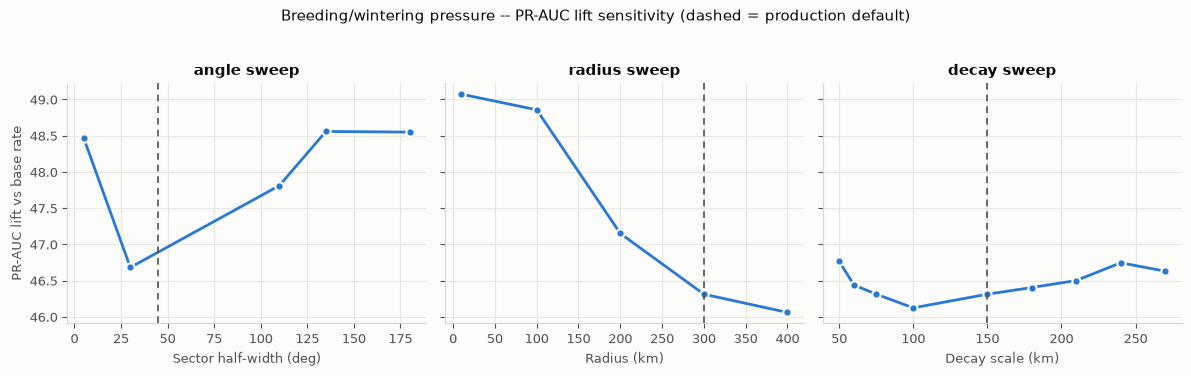

In [19]:
# --- visualize: PR-AUC lift as each parameter moves away from the production default ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
sweep_specs = [
    ("angle",  "angle_deg",  "Sector half-width (deg)", PRODUCTION_ANGLE),
    ("radius", "radius_km",  "Radius (km)",              PRODUCTION_RADIUS),
    ("decay",  "decay_km",   "Decay scale (km)",         PRODUCTION_DECAY),
]
for ax, (sweep_name, xcol, xlabel, prod_val) in zip(axes, sweep_specs):
    sub = results_df[results_df.sweep == sweep_name].sort_values(xcol)
    ax.plot(sub[xcol], sub.lift, color=BLUE, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.axvline(prod_val, color=INK_2, lw=1.2, ls=(0, (4, 3)))
    ax.set(xlabel=xlabel, title=f"{sweep_name} sweep")

axes[0].set_ylabel("PR-AUC lift vs base rate")
fig.suptitle("Breeding/wintering pressure -- PR-AUC lift sensitivity (dashed = production default)",
             fontsize=10.5, color=INK, y=1.03)
fig.tight_layout()
plt.show()

## Interpretation of angle, radius, and decay sweep

<u>Angles</u>
We start with high PR-AUC/base rate at zero degrees, but it is possible within the number range-wise. When we think about it realistically, there will be no neighbors considered at all, and it is behaving as if removing the neighbor county as a feature. Also, the migration axis is a float, and it is very rare to match the migration axis to the county location axis, since county centroids span multiple axes. 
There is a decrease in PR-AUC/base rate until it hits 45 degrees, and then the rate increases at 120 degrees. It plateau around that period and peaks at 160 degree.   

<u>Radius</u>
The radius graph shows a very interesting trend, which is that the shortest radius distances have a high PR-AUC/base rate that peaks at 40-60 km. Then it decreases at that rate after that.

<u>Decay</u>
For the decay sweep, it decreases from 1/6 and then increases in trend and peaks at 6/10.  

## Best angle, radius, and decay for Logistic Regression Model

| Variable | Optimal |
|----------|---------|
| Angle | 160 Degree |
| Distance | 40-60 km |
| Decay | 1/6, 6/10 - 7/10 |

## 8. Independent/Explaining variables standard errors, CI, significant from using optimal angle, radius, and decay in logistic regression model

Next, we will examine the statistical inference relating to which variables are significant in explaining the target variable here, which is the target outbreak in the next 7 days. 

In [20]:
# --- refit section 5's clustered-SE inference at the sweep-optimal side-pressure geometry ---
# Section 5 used the production geometry (45 deg / 300 km / 150 km). Section 7's sweep
# pointed to 160 deg / 40-60 km / 6/10-7/10 decay instead, so we rebuild breeding/wintering
# side pressure at that combo and rerun the SAME clustered-SE fit to see whether the
# coefficients (odds ratios, CIs, significance) hold up under it.
# Decay is expressed as a fraction OF THE RADIUS being used here (same convention as
# section "Testing Range": "DECAY_SCALE_KM = 150 or 1/2 of the distance"), so
# 6/10 decay at a 60 km radius is 36 km -- not the 180 km that 6/10 meant in the decay
# sweep, which held radius fixed at the 300 km production default.
OPTIMAL_ANGLE, OPTIMAL_RADIUS, OPTIMAL_DECAY_FRAC = 160.0, 60.0, 6 / 10
OPTIMAL_DECAY = OPTIMAL_RADIUS * OPTIMAL_DECAY_FRAC  # 36 km

frame_opt = with_side_pressure(OPTIMAL_ANGLE, OPTIMAL_RADIUS, OPTIMAL_DECAY)
X_opt = build_X(frame_opt)
y_opt = frame_opt.target_outbreak_next_7d.astype(int)
train_opt = frame_opt.day < SPLIT_DATE
X_tr_opt, y_tr_opt = X_opt[train_opt], y_opt[train_opt]

Xs_opt = (X_tr_opt - X_tr_opt.mean()) / X_tr_opt.std().replace(0, 1)   # standardized -> comparable ORs
Xs_opt = sm.add_constant(Xs_opt, has_constant="add")

res_opt = sm.Logit(y_tr_opt.values, Xs_opt).fit(
    disp=False, method="lbfgs", maxiter=200,
    cov_type="cluster", cov_kwds={"groups": frame_opt.loc[train_opt, "fips"].values},
)

ci_opt = np.asarray(res_opt.conf_int())
coef_opt = pd.DataFrame({
    "odds_ratio": np.exp(np.asarray(res_opt.params)),
    "ci_low":     np.exp(ci_opt[:, 0]),
    "ci_high":    np.exp(ci_opt[:, 1]),
    "p_value":    np.asarray(res_opt.pvalues),
}, index=Xs_opt.columns)
coef_opt["significant"] = coef_opt.p_value < 0.05
coef_opt = coef_opt.drop("const").sort_values("odds_ratio", ascending=False)   # kept for the odds-ratio plot below

print("Odds ratio per 1 SD increase, at angle=160 deg / radius=60 km / decay=36 km (6/10 of radius). "
      f"Clustered by county (n_clusters = {frame_opt.loc[train_opt, 'fips'].nunique():,}).\n")

# --- rank by CI precision instead of effect size: narrowest (most tightly estimated) ---
# --- confidence interval first, all variables shown, not just a top-N cut ------------
coef_opt["ci_width"] = coef_opt.ci_high - coef_opt.ci_low
by_ci_opt = coef_opt.sort_values("ci_width", ascending=True)
pd.set_option("display.max_rows", None)
print(f"All {len(by_ci_opt)} variables, ranked by confidence-interval width -- narrowest "
      "(most precisely estimated) first:\n")
display(by_ci_opt[["odds_ratio", "ci_low", "ci_high", "ci_width", "p_value", "significant"]].style.format(
    {"odds_ratio": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}", "ci_width": "{:.3f}", "p_value": "{:.2e}"}))

Odds ratio per 1 SD increase, at angle=160 deg / radius=60 km / decay=36 km (6/10 of radius). Clustered by county (n_clusters = 3,108).

All 36 variables, ranked by confidence-interval width -- narrowest (most precisely estimated) first:



,odds_ratio,ci_low,ci_high,ci_width,p_value,significant
weather_missing,0.884,0.865,0.902,0.037,1.16e-30,True
log_wild_detections_7d,1.042,1.003,1.083,0.080,3.37e-02,True
log_nbr_wild_detections_7d,1.064,1.019,1.110,0.091,4.66e-03,True
log_own_outbreaks_7d,1.189,1.138,1.241,0.103,5.36e-15,True
log_wild_detections_21d,1.092,1.033,1.155,0.123,2.10e-03,True
doy_sin,0.771,0.709,0.837,0.128,8.23e-10,True
precip_7d_mm,0.945,0.877,1.017,0.140,1.32e-01,False
log_own_outbreaks_21d,1.156,1.088,1.229,0.141,2.72e-06,True
log_wild_detections_60d,0.985,0.914,1.060,0.146,6.79e-01,False
layer_inventory_suppressed,1.106,1.035,1.182,0.147,2.91e-03,True


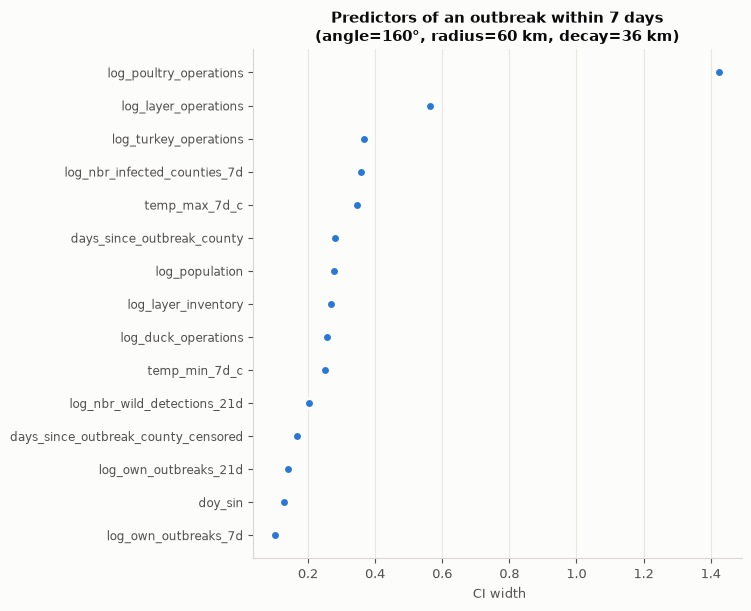

In [21]:
top_opt = pd.concat([coef_opt.head(9), coef_opt.tail(6)]).sort_values("ci_width", ascending=True)
fig, ax = plt.subplots(figsize=(7.6, 6.2))
ypos = np.arange(len(top_opt))

# ax.hlines(ypos, top_opt.ci_low, top_opt.ci_high, color=BLUE, lw=2, alpha=0.45)
ax.plot(top_opt.ci_width, ypos, "o", color=BLUE, markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2, linestyle="none")
# ax.axvline(1.0, color=INK_2, lw=1.2, ls=(0, (4, 3)))

ax.set_yticks(ypos)
ax.set_yticklabels(top_opt.index, fontsize=8.5)
# ax.set_xscale("log")
ax.set(xlabel=" CI width",
       title="Predictors of an outbreak within 7 days\n(angle=160°, radius=60 km, decay=36 km)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

### Interpretation and Comparison

* The significance of the variable p-value is measured by a value lower than 0.05 or 5 x $10^{-2}$
* The tables in sections 5 and 8 now rank **all** variables by confidence-interval width, narrowest
  (most precisely estimated) first, instead of cutting to a top-12-by-odds-ratio window. Every
  variable that goes into the model is shown in both tables, so this comparison is no longer subject
  to the earlier "only in one table's top 12" selection effect -- any remaining differences below are
  genuine changes in significance or precision between the two side-pressure geometries.
* It is worth noting that the optimized condition of 160 degrees and 60 km radius is a wide rotation
  and short radius, so this might be on the extreme for angle and radius km usage.

#### The significant and high confidence variables from optimized angle, distance, decay model

|Non Optimized Model |Optimized Angle, Distance, Decay Model|
|--------------------|--------------------------------------|
|weather_missing|weather_missing|
|log_own_outbreaks_7d|log_nbr_wild_detections_7d|
|log_wild_detections_21d|log_own_outbreaks_7d|
|log_breeding_side_pressure|log_wild_detections_21d|
|log_wintering_side_pressure|doy_sin|
|doy_sin|log_own_outbreaks_21d|
|log_own_outbreaks_21d|layer_inventory_suppressed|
|layer_inventory_suppressed|log_own_outbreaks_60d|
|log_own_outbreaks_60d||
|log_nbr_wild_detections_7d||

In this table, I chose all the variables that have a confidence interval < 0.2 and significance lower than 0.05. 
There are some variables that do not make sense to be an explanatory variable, such as weather missing and doy sin or cos. 
Those are only indicators and do not do any explaining it self.

#### Suggested Important Variables to Use Moving Forward

| Significant Variable with CI < 0.2 From Logistic Regression Model|
|--------------------------------------------------------|
|log_nbr_wild_detections_7d|
|log_own_outbreaks_7d|
|log_wild_detections_21d|
|log_own_outbreaks_21d|
|layer_inventory_suppressed|
|log_own_outbreaks_60d|

| Significant Variable with 2.0< CI < 1.0 From Logistic Regression Model|
|------------------------------------------------------------------|
|log_nbr_wild_detections_21d|
|temp_min_7d_c|
|log_layer_inventory|
|log_population|	
|log_turkey_operations|
|log_layer_operations|

**Note Discussion With Group** : 
* log_breeding_side_pressure and log_wintering_side_pressure matter significantly in the 45 degree, 300 km radius, and 1/2 decay. On the other hand, they do not matter in the 160 degree, 60 km, and 6/10 decay.
* How much confidence width should really be the cutoff point. All the variables, except one, has confidence interval under 1.0, which is pretty confidence.
* Temperature and weather seem not to play a big role in being the predictor of the outbreak, which not the same as the analysis in Zou's paper. This also might be because our table right now have less weather variables when compared to the Zou's analysis. Our Logistic regression so far agrees with the fact that the population of the flocks significantly impacts the outbreak. 

## 9. Multicollinearity

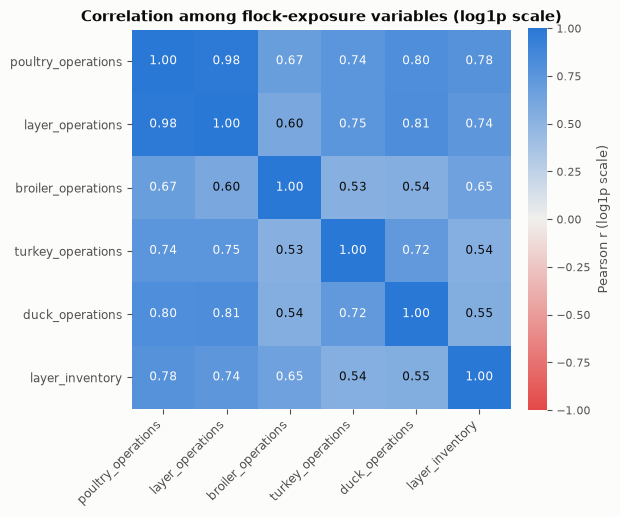

Pairs with |r| > 0.8 (3 of 36 total pairs):

poultry_operations  layer_operations    +0.982
layer_operations    duck_operations     +0.815
poultry_operations  duck_operations     +0.805


In [22]:
FLOCK_COLS = [
    "poultry_operations", "layer_operations", "broiler_operations",
    "turkey_operations", "duck_operations", "layer_inventory",
]

# log1p to match the scale these variables actually enter the model at (section 2) --
# correlating the raw, heavily right-skewed counts would just be dominated by a
# handful of huge egg-belt counties.
flock_log = np.log1p(df[FLOCK_COLS].clip(lower=0))
corr = flock_log.corr()

from matplotlib.colors import LinearSegmentedColormap

RED = "#e34948"
diverging = LinearSegmentedColormap.from_list("blue_gray_red", [RED, "#f0efec", BLUE])

fig, ax = plt.subplots(figsize=(6.2, 5.6))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)

n = len(FLOCK_COLS)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(FLOCK_COLS, rotation=45, ha="right", fontsize=8.5)
ax.set_yticklabels(FLOCK_COLS, fontsize=8.5)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n):
    for j in range(n):
        r = corr.iloc[i, j]
        ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=8.5,
                color=SURFACE if abs(r) > 0.6 else INK)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r (log1p scale)", color=INK_2, fontsize=9)
cbar.ax.tick_params(colors=INK_2, labelsize=8)
cbar.outline.set_visible(False)

ax.set_title("Correlation among flock-exposure variables (log1p scale)")
fig.tight_layout()
plt.show()

# --- flag pairs a modeler would actually worry about ---------------------------
# |r| > 0.8 is the common rule-of-thumb threshold where multicollinearity starts
# distorting individual coefficient estimates, even though the joint fit still
# predicts fine.
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("r")
        .sort_values(key=abs, ascending=False)
)
high = pairs[pairs.abs() > 0.8]
print(f"Pairs with |r| > 0.8 ({len(high)} of {len(pairs)} total pairs):\n")
print(high.map("{:+.3f}".format).to_string() if len(high) else "  (none)")

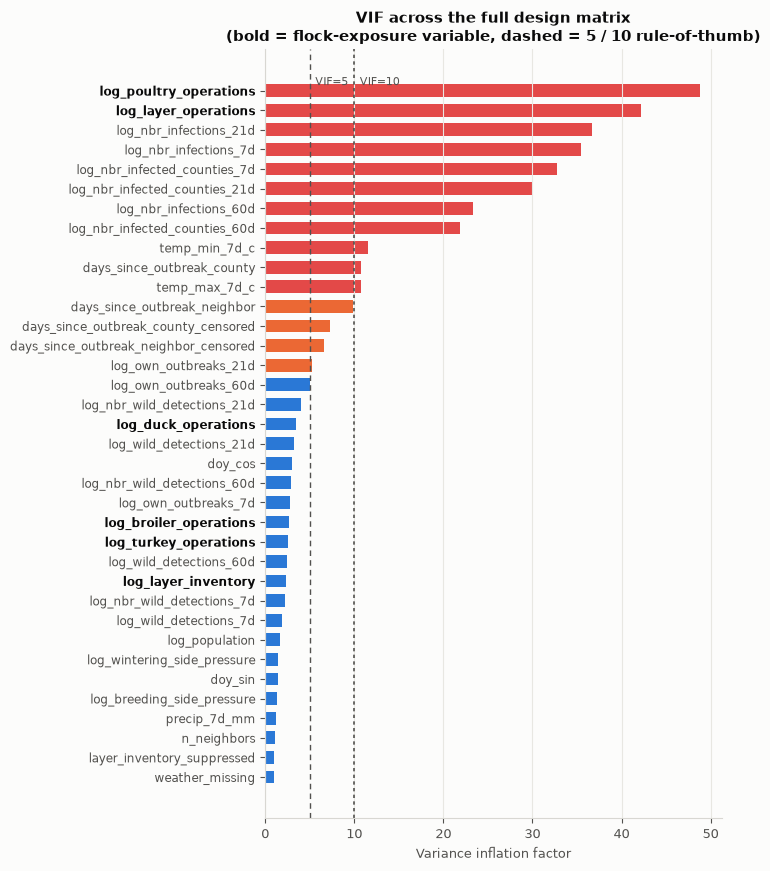

Flock-exposure variables, ranked by VIF:

log_poultry_operations    48.78
log_layer_operations      42.13
log_duck_operations        3.43
log_broiler_operations     2.63
log_turkey_operations      2.59
log_layer_inventory        2.32

All variables with VIF > 5 (moderate) or > 10 (serious) collinearity:
log_poultry_operations                   48.78
log_layer_operations                     42.13
log_nbr_infections_21d                   36.72
log_nbr_infections_7d                    35.43
log_nbr_infected_counties_7d             32.79
log_nbr_infected_counties_21d            29.96
log_nbr_infections_60d                   23.30
log_nbr_infected_counties_60d            21.87
temp_min_7d_c                            11.50
days_since_outbreak_county               10.79
temp_max_7d_c                            10.73
days_since_outbreak_neighbor              9.89
days_since_outbreak_county_censored       7.32
days_since_outbreak_neighbor_censored     6.61
log_own_outbreaks_21d                

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.Series(
    [variance_inflation_factor(Xs.values, i) for i in range(Xs.shape[1])],
    index=Xs.columns,
).drop("const").sort_values(ascending=False)

flock_log_cols = [f"log_{c}" for c in FLOCK_COLS]
is_flock = vif.index.isin(flock_log_cols)

fig, ax = plt.subplots(figsize=(7.4, 8.8))
ypos = np.arange(len(vif))
bar_colors = [RED if v > 10 else (ORANGE if v > 5 else BLUE) for v in vif.values]
ax.barh(ypos, vif.values, color=bar_colors, height=0.65)
ax.axvline(5, color=INK_2, lw=1.0, ls=(0, (4, 3)))
ax.axvline(10, color=INK_2, lw=1.2, ls=(0, (2, 2)))
ax.annotate("VIF=5", (5, 0), textcoords="offset points", xytext=(4, 4), fontsize=8, color=INK_2)
ax.annotate("VIF=10", (10, 0), textcoords="offset points", xytext=(4, 4), fontsize=8, color=INK_2)

ax.set_yticks(ypos)
labels = ax.set_yticklabels(vif.index, fontsize=8.5)
for label, flock in zip(labels, is_flock):
    if flock:
        label.set_fontweight("bold")
        label.set_color(INK)

ax.invert_yaxis()   # largest VIF at top
ax.set(xlabel="Variance inflation factor",
       title="VIF across the full design matrix" + chr(10) + "(bold = flock-exposure variable, dashed = 5 / 10 rule-of-thumb)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

print("Flock-exposure variables, ranked by VIF:" + chr(10))
print(vif[is_flock].map("{:.2f}".format).to_string())
print("" + chr(10) + "All variables with VIF > 5 (moderate) or > 10 (serious) collinearity:")
over5 = vif[vif > 5]
print(over5.map("{:.2f}".format).to_string() if len(over5) else "  (none)")


<u> Summary: </u>
* log_poultry_operations and log_layer_operations were confirmed to have multicollinearity
* log_nbr_infections_21d and log_nbr_infections_7d have multicollinearity, which makes sense
* log_nbr_infected_counties_7d and log_nbr_infected_counties_21d have multicollinearity
* log_nbr_infections_60d and log_nbr_infected_counties_60d have multicollinearity
* bottomline: keep poultry and not layer, and for other variables that have multicollinearity make sure to only choose one in the final variables for a baseline model

# 10. Tree Model
- remove log layer operations
- simple vs ensemble tree model
- compare performance in each model, the best performing model we will look into variable importance

## 10.1. Simple Tree Model


In [24]:
from sklearn.tree import DecisionTreeClassifier

# Section 9 (VIF + correlation) found log_poultry_operations and log_layer_operations
# collinear -- keeping both just splits variance between them without adding information.
# poultry_operations is the broader count (layer_operations is a subset of it), so it's
# kept and log_layer_operations is dropped here, per the section 9 summary.
TREE_DROP_COLS = ["log_layer_operations"]
X_tr_tree = X_tr.drop(columns=TREE_DROP_COLS)
X_te_tree = X_te.drop(columns=TREE_DROP_COLS)

# Trees have no interceptable log-odds, so the analytic case-control correction from
# section 3 doesn't apply here. The weighted equivalent: give each kept training negative
# a weight of 1 / NEG_SAMPLE_RATE (it stands in for the ~20 negatives that were NOT
# sampled), so the tree's splits and leaf-node probabilities are fit against the true
# population balance instead of the artificially-enriched 4.7% training rate.
sample_weight_tr = np.where(y_tr.values == 1, 1.0, 1.0 / NEG_SAMPLE_RATE)

# Deliberately shallow and not hyperparameter-searched -- this is the interpretable
# baseline tree, same "untuned reference" spirit as the logistic regression above.
tree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=200, random_state=RANDOM_STATE)
tree.fit(X_tr_tree, y_tr, sample_weight=sample_weight_tr)

p_te_tree = tree.predict_proba(X_te_tree)[:, 1]

scores_tree = pd.Series({
    "test rows":            f"{len(y_te):,}",
    "test positives":       f"{int(y_te.sum()):,}",
    "base rate":            f"{base_rate:.4%}",
    "ROC-AUC":              f"{roc_auc_score(y_te, p_te_tree):.4f}",
    "PR-AUC (avg prec.)":   f"{average_precision_score(y_te, p_te_tree):.4f}",
    "PR-AUC lift vs base":  f"{average_precision_score(y_te, p_te_tree) / base_rate:.1f}x",
    "Brier score":          f"{brier_score_loss(y_te, p_te_tree):.6f}",
    "mean predicted prob":  f"{p_te_tree.mean():.4%}",
})

comparison = pd.DataFrame({
    "logistic (36 vars)": scores,
    "tree (35 vars, no log_layer_operations)": scores_tree,
})
display(comparison)
print("Sample weighting makes the tree comparable to the logistic model's corrected")
print("probabilities -- both should land with mean predicted prob near the true base rate.")


,logistic (36 vars),"tree (35 vars, no log_layer_operations)"
test rows,"1,740,480","1,740,480"
test positives,"4,366","4,366"
base rate,0.2509%,0.2509%
ROC-AUC,0.8759,0.8410
PR-AUC (avg prec.),0.1162,0.0939
PR-AUC lift vs base,46.3x,37.5x
Brier score,0.002545,0.002361
mean predicted prob,0.3768%,0.2849%


Sample weighting makes the tree comparable to the logistic model's corrected
probabilities -- both should land with mean predicted prob near the true base rate.


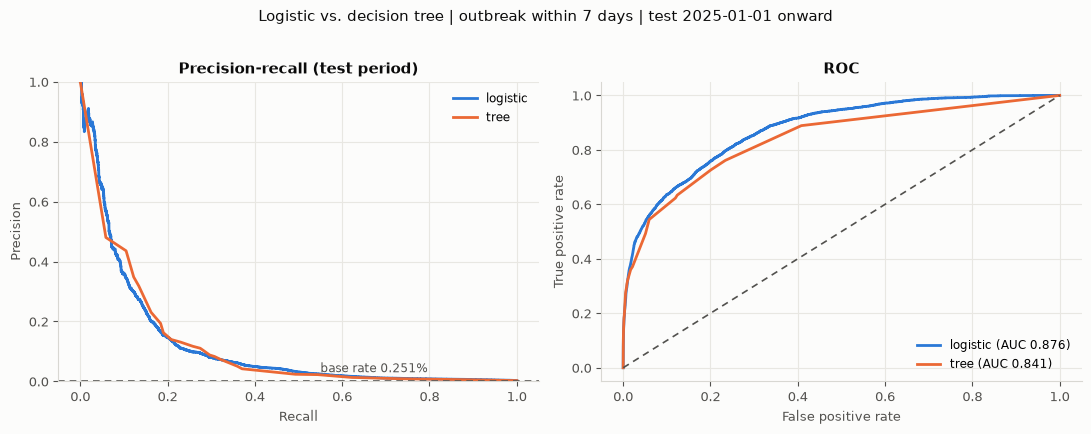

In [25]:
# --- same comparison the logistic baseline got in section 4: PR and ROC, overlaid ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

prec_lr, rec_lr, _ = precision_recall_curve(y_te, p_te)
prec_tr, rec_tr, _ = precision_recall_curve(y_te, p_te_tree)
axes[0].plot(rec_lr, prec_lr, color=BLUE, label="logistic")
axes[0].plot(rec_tr, prec_tr, color=ORANGE, label="tree")
axes[0].axhline(base_rate, color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[0].annotate(f"base rate {base_rate:.3%}", (0.55, base_rate), textcoords="offset points",
                 xytext=(0, 6), color=INK_2, fontsize=8.5)
axes[0].set(xlabel="Recall", ylabel="Precision", ylim=(0, 1), title="Precision-recall (test period)")
axes[0].legend(loc="upper right", fontsize=8.5)

fpr_lr, tpr_lr, _ = roc_curve(y_te, p_te)
fpr_tr, tpr_tr, _ = roc_curve(y_te, p_te_tree)
axes[1].plot(fpr_lr, tpr_lr, color=BLUE, label=f"logistic (AUC {roc_auc_score(y_te, p_te):.3f})")
axes[1].plot(fpr_tr, tpr_tr, color=ORANGE, label=f"tree (AUC {roc_auc_score(y_te, p_te_tree):.3f})")
axes[1].plot([0, 1], [0, 1], color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC")
axes[1].legend(loc="lower right", fontsize=8.5)

fig.suptitle(f"Logistic vs. decision tree | outbreak within 7 days | test {SPLIT_DATE} onward",
             fontsize=10.5, color=INK, y=1.02)
fig.tight_layout()
plt.show()


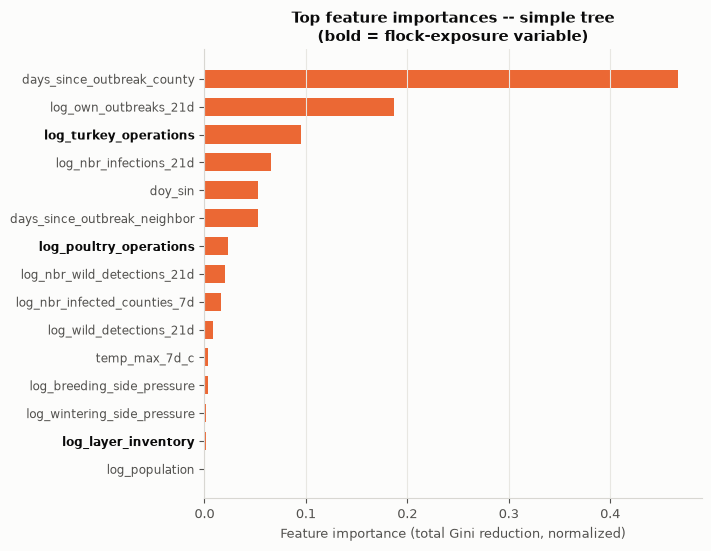

20 of 35 variables get zero importance
(never used as a split at max_depth=6) -- a feature the tree ignores entirely,
unlike the logistic fit where every variable gets a coefficient regardless of value.


In [26]:
# --- top feature importances for the simple tree -------------------------------
# DecisionTreeClassifier.feature_importances_ is the (normalized) total reduction in
# weighted Gini impurity each variable is responsible for across every split it's used
# in -- the tree's analog to the logistic model's odds ratios in section 5, but it
# carries no sign and isn't per-unit, just "how much of the tree's splitting power
# came from this variable."
importances = pd.Series(tree.feature_importances_, index=X_tr_tree.columns).sort_values(ascending=False)
top_n = importances[importances > 0].head(15)

flock_log_cols = [f"log_{c}" for c in FLOCK_COLS if c != "layer_operations"]
is_flock = top_n.index.isin(flock_log_cols)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ypos = np.arange(len(top_n))
ax.barh(ypos, top_n.values, color=ORANGE, height=0.65)

ax.set_yticks(ypos)
labels = ax.set_yticklabels(top_n.index, fontsize=8.5)
for label, flock in zip(labels, is_flock):
    if flock:
        label.set_fontweight("bold")
        label.set_color(INK)

ax.invert_yaxis()   # largest importance at top
ax.set(xlabel="Feature importance (total Gini reduction, normalized)",
       title="Top feature importances -- simple tree\n(bold = flock-exposure variable)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

print(f"{(importances == 0).sum()} of {len(importances)} variables get zero importance")
print("(never used as a split at max_depth=6) -- a feature the tree ignores entirely,")
print("unlike the logistic fit where every variable gets a coefficient regardless of value.")


## What if we used optimized angle, radius, decay to the tree model?

In [27]:
# --- same tree procedure as 10.1, but on the OPTIMIZED side-pressure geometry ---
# Section 8 built frame_opt / X_opt / y_opt at OPTIMAL_ANGLE / OPTIMAL_RADIUS /
# OPTIMAL_DECAY (160 deg / 60 km / 36 km) but only split off the training rows
# (X_tr_opt, y_tr_opt) for its clustered-SE refit. The tree also needs the test
# half, so that split is completed here.
test_opt = frame_opt.day >= SPLIT_DATE
X_te_opt, y_te_opt = X_opt[test_opt], y_opt[test_opt]

X_tr_tree_opt = X_tr_opt.drop(columns=TREE_DROP_COLS)
X_te_tree_opt = X_te_opt.drop(columns=TREE_DROP_COLS)

# Same inverse-probability sample weighting as 10.1 -- frame_opt's training window
# went through the identical case-control negative sampling as df, so it needs the
# identical correction.
sample_weight_tr_opt = np.where(y_tr_opt.values == 1, 1.0, 1.0 / NEG_SAMPLE_RATE)

tree_opt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=200, random_state=RANDOM_STATE)
tree_opt.fit(X_tr_tree_opt, y_tr_opt, sample_weight=sample_weight_tr_opt)

p_te_tree_opt = tree_opt.predict_proba(X_te_tree_opt)[:, 1]
base_rate_opt = y_te_opt.mean()   # should match base_rate -- same rows, same target, same split date

scores_tree_opt = pd.Series({
    "test rows":            f"{len(y_te_opt):,}",
    "test positives":       f"{int(y_te_opt.sum()):,}",
    "base rate":            f"{base_rate_opt:.4%}",
    "ROC-AUC":              f"{roc_auc_score(y_te_opt, p_te_tree_opt):.4f}",
    "PR-AUC (avg prec.)":   f"{average_precision_score(y_te_opt, p_te_tree_opt):.4f}",
    "PR-AUC lift vs base":  f"{average_precision_score(y_te_opt, p_te_tree_opt) / base_rate_opt:.1f}x",
    "Brier score":          f"{brier_score_loss(y_te_opt, p_te_tree_opt):.6f}",
    "mean predicted prob":  f"{p_te_tree_opt.mean():.4%}",
})

comparison_opt = pd.DataFrame({
    "logistic (production geom.)":       scores,
    "tree (production geom.)":           scores_tree,
    "tree (optimized geom. 160/60/36)":  scores_tree_opt,
})
display(comparison_opt)
print("Compare the last two columns to see whether the section 7 sweep's optimal")
print("angle/radius/decay actually helps the TREE, not just the logistic model in section 8.")


,logistic (production geom.),tree (production geom.),tree (optimized geom. 160/60/36)
test rows,"1,740,480","1,740,480","1,740,480"
test positives,"4,366","4,366","4,366"
base rate,0.2509%,0.2509%,0.2509%
ROC-AUC,0.8759,0.8410,0.8394
PR-AUC (avg prec.),0.1162,0.0939,0.0935
PR-AUC lift vs base,46.3x,37.5x,37.3x
Brier score,0.002545,0.002361,0.002361
mean predicted prob,0.3768%,0.2849%,0.2797%


Compare the last two columns to see whether the section 7 sweep's optimal
angle/radius/decay actually helps the TREE, not just the logistic model in section 8.


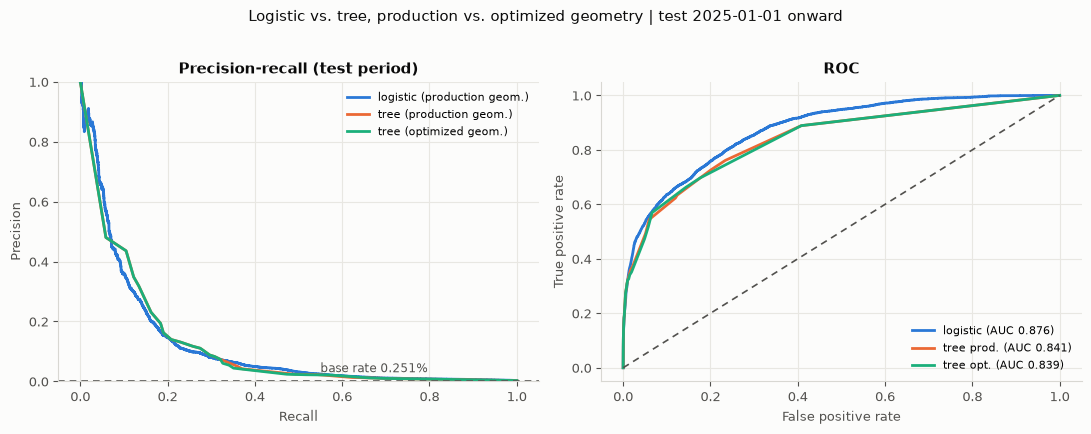

In [28]:
# --- PR/ROC comparison: logistic vs. tree at each geometry, all on the same axes ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

prec_lr, rec_lr, _ = precision_recall_curve(y_te, p_te)
prec_tr, rec_tr, _ = precision_recall_curve(y_te, p_te_tree)
prec_to, rec_to, _ = precision_recall_curve(y_te_opt, p_te_tree_opt)
axes[0].plot(rec_lr, prec_lr, color=BLUE, label="logistic (production geom.)")
axes[0].plot(rec_tr, prec_tr, color=ORANGE, label="tree (production geom.)")
axes[0].plot(rec_to, prec_to, color=AQUA, label="tree (optimized geom.)")
axes[0].axhline(base_rate, color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[0].annotate(f"base rate {base_rate:.3%}", (0.55, base_rate), textcoords="offset points",
                 xytext=(0, 6), color=INK_2, fontsize=8.5)
axes[0].set(xlabel="Recall", ylabel="Precision", ylim=(0, 1), title="Precision-recall (test period)")
axes[0].legend(loc="upper right", fontsize=8)

fpr_lr, tpr_lr, _ = roc_curve(y_te, p_te)
fpr_tr, tpr_tr, _ = roc_curve(y_te, p_te_tree)
fpr_to, tpr_to, _ = roc_curve(y_te_opt, p_te_tree_opt)
axes[1].plot(fpr_lr, tpr_lr, color=BLUE, label=f"logistic (AUC {roc_auc_score(y_te, p_te):.3f})")
axes[1].plot(fpr_tr, tpr_tr, color=ORANGE, label=f"tree prod. (AUC {roc_auc_score(y_te, p_te_tree):.3f})")
axes[1].plot(fpr_to, tpr_to, color=AQUA, label=f"tree opt. (AUC {roc_auc_score(y_te_opt, p_te_tree_opt):.3f})")
axes[1].plot([0, 1], [0, 1], color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC")
axes[1].legend(loc="lower right", fontsize=8)

fig.suptitle(f"Logistic vs. tree, production vs. optimized geometry | test {SPLIT_DATE} onward",
             fontsize=10.5, color=INK, y=1.02)
fig.tight_layout()
plt.show()


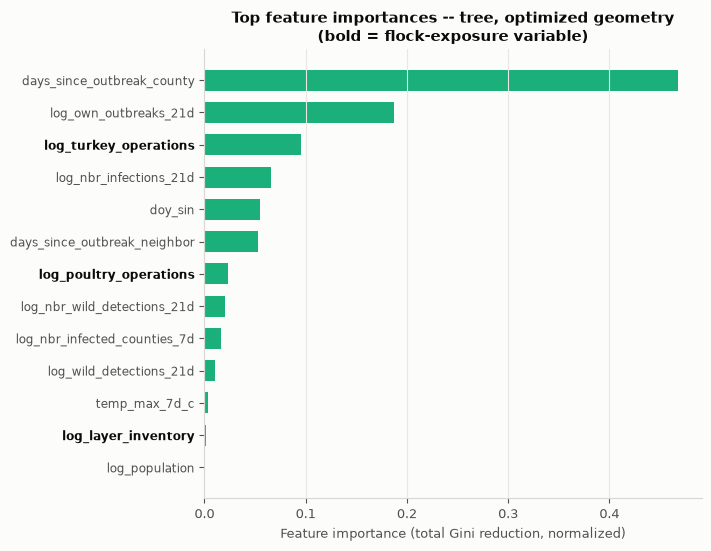

22 of 35 variables get zero importance.

Top 10 variables, production vs. optimized geometry importance side by side:


,production geom.,optimized geom.
days_since_outbreak_county,0.4667,0.4677
log_own_outbreaks_21d,0.1864,0.1868
log_turkey_operations,0.0949,0.0951
log_nbr_infections_21d,0.0659,0.0660
doy_sin,0.0527,0.0544
days_since_outbreak_neighbor,0.0526,0.0527
log_poultry_operations,0.0235,0.0235
log_nbr_wild_detections_21d,0.0201,0.0202
log_nbr_infected_counties_7d,0.0168,0.0168
log_wild_detections_21d,0.0087,0.0106


In [29]:
# --- top feature importances for the optimized-geometry tree -------------------
importances_opt = pd.Series(tree_opt.feature_importances_, index=X_tr_tree_opt.columns).sort_values(ascending=False)
top_n_opt = importances_opt[importances_opt > 0].head(15)

is_flock_opt = top_n_opt.index.isin(flock_log_cols)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ypos = np.arange(len(top_n_opt))
ax.barh(ypos, top_n_opt.values, color=AQUA, height=0.65)

ax.set_yticks(ypos)
labels = ax.set_yticklabels(top_n_opt.index, fontsize=8.5)
for label, flock in zip(labels, is_flock_opt):
    if flock:
        label.set_fontweight("bold")
        label.set_color(INK)

ax.invert_yaxis()   # largest importance at top
ax.set(xlabel="Feature importance (total Gini reduction, normalized)",
       title="Top feature importances -- tree, optimized geometry\n(bold = flock-exposure variable)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

print(f"{(importances_opt == 0).sum()} of {len(importances_opt)} variables get zero importance.")

# --- did the winning split variables actually change between geometries? -------
changed = pd.DataFrame({
    "production geom.": importances.reindex(importances_opt.index).fillna(0),
    "optimized geom.":  importances_opt,
}).sort_values("optimized geom.", ascending=False)
print("\nTop 10 variables, production vs. optimized geometry importance side by side:")
display(changed.head(10).style.format("{:.4f}"))
